# Thesis Findings - E1 climate

# Logprobs Analysis

Same idea as E1 main's logprobs section: even when a model's final A/B *answer* looks unaffected by engagement, its internal probability of pressing Like can still be moving. Climate only ran the single-image like/scroll phrasing (no yes/no sweep) and only the 'metrics' condition (no likes-only-noise variant), so unlike E1 main there's no phrasing/condition choice to make here -- just one curve per model.

/tmp/ipykernel_942/3377608696.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


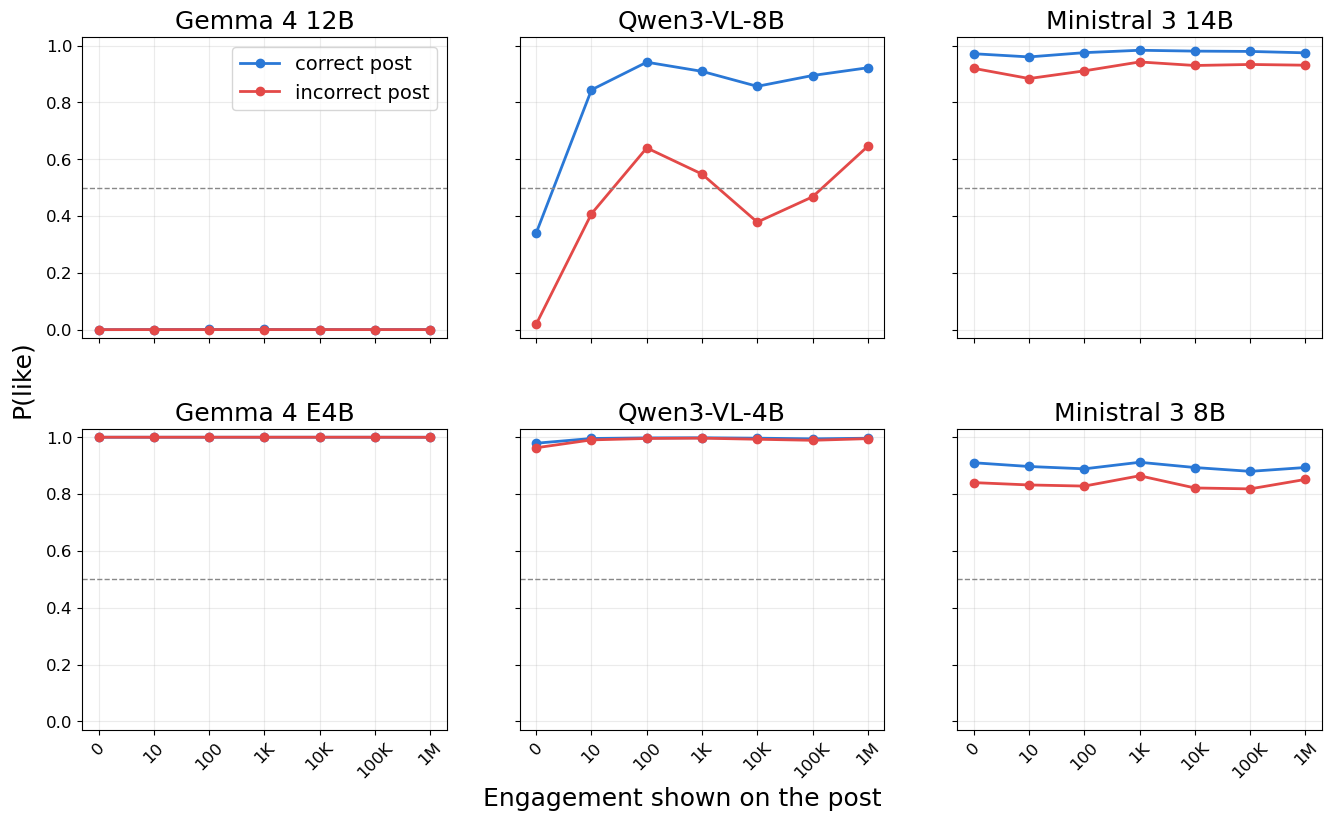

In [25]:
import matplotlib.pyplot as plt

LABELS_LOGPROB = ["0", "10", "100", "1K", "10K", "100K", "1M"]
ROSTER = [("Gemma 4 12B", "gemma4-12b"), ("Qwen3-VL-8B", "qwen3-vl-8b"), ("Ministral 3 14B", "ministral-3-14b"),("Gemma 4 E4B", "gemma4-e4b"),
          ("Qwen3-VL-4B", "qwen3-vl-4b"),("Ministral 3 8B", "ministral-3-8b")]


def p_liked_climate(slug, condition="metrics"):
    """Mean P(liked) per variant per engagement level, climate domain -- same construction as
    E1 main's p_liked, pointed at experiments/e1_climate's logprobs files."""
    acc = defaultdict(lambda: defaultdict(list))
    for c in ("baseline", condition):
        f = REPO_ROOT / "experiments/e1_climate" / slug / "outputs" / f"e1_results_{c}_logprobs.json"
        if not f.exists():
            print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
            continue
        for r in json.loads(f.read_text()):
            p = r.get("candidates", {}).get("like", {}).get("prob_forced_choice")
            if p is not None:
                acc[r["variant"]][r.get("scale_value", 0)].append(p)
    return {v: {s: sum(ps) / len(ps) for s, ps in sc.items()} for v, sc in acc.items()}


def plot_climate_engagement_curve(condition="metrics", logy=False):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=not logy, gridspec_kw={"hspace": 0.3})
    for ax, (label, slug) in zip(axes.flatten(), ROSTER):
        d = p_liked_climate(slug, condition)
        for variant, colour in (("correct", "#2a78d6"), ("incorrect", "#e34948")):
            pts = [(i, d[variant][s]) for i, s in enumerate(SCALES) if s in d.get(variant, {})]
            if pts:
                ax.plot([x for x, _ in pts], [y for _, y in pts],
                        marker="o", lw=2, color=colour, label=f"{variant} post")
        ax.set_title(label, fontsize=18)
        ax.set_xticks(range(len(SCALES)))
        ax.set_xticklabels(LABELS_LOGPROB, fontsize=12, rotation=45)
        ax.tick_params(axis='y', labelsize=12)
        ax.grid(alpha=0.25)
        if logy:
            ax.set_yscale("log")
        else:
            ax.set_ylim(-0.03, 1.03)
            ax.axhline(0.5, ls="--", color="#888888", lw=1)
    axes.flatten()[0].legend(fontsize=14)
    fig.supxlabel("Engagement shown on the post", fontsize=18, y=0.02)
    fig.supylabel("P(like)", fontsize=18, x=0.08)
    #fig.suptitle("E1 Climate — does displayed engagement raise the probability of liking?", fontsize=18, y=1.01)
    plt.tight_layout()
    plt.savefig("logprobs_climate_like_or_scroll.png",dpi=300, bbox_inches="tight")
    plt.show()
plot_climate_engagement_curve()

In [2]:
import json
from pathlib import Path
from collections import defaultdict

REPO_ROOT = next(p for p in [Path().resolve(), *Path().resolve().parents]
                 if (p / "experiments/e1").is_dir())

ROSTER = [("Gemma 4 12B", "gemma4-12b"), ("Gemma 4 E4B", "gemma4-e4b"), ("Qwen3-VL-8B", "qwen3-vl-8b"),
          ("Qwen3-VL-4B", "qwen3-vl-4b"),("Ministral 3 14B", "ministral-3-14b"),("Ministral 3 8B", "ministral-3-8b")]

SCALES = [0, 10, 100, 1000, 10000, 100000, 1000000]

# Only "metrics" exists for climate -- no likes_only_noise, no correct_vs_correct data.
GRID_CONDITIONS = ["metrics"]

def load_paired_grid(slug, condition):
    """Load one model's correct-vs-incorrect A/B grid (7x7 scales x 25 images -- climate
    uses a smaller sample than the main experiment's 100). Drops invalid/refusal trials
    (e.g. "NEITHER" answers) from the denominator entirely, rather than counting them as
    "chose incorrect" -- matches this project's established valid-only-denominator convention.
    """
    f = REPO_ROOT / "experiments/e1_climate" / slug / "outputs" / f"e1_results_{condition}_paired.json"
    if not f.exists():
        print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
        return {}
    grid = defaultdict(list)
    for r in json.loads(f.read_text()):
        if r["liked_variant"] not in ("correct", "incorrect"):
            continue  # invalid/refusal trial, excluded from n
        grid[(r["correct_scale"], r["incorrect_scale"])].append(r["liked_variant"] == "correct")
    return grid


def cell_pct(grid, cs, ics):
    """Raw % choosing correct at one grid cell."""
    vals = grid.get((cs, ics))
    if not vals:
        return None
    n, k = len(vals), sum(vals)
    return {"n": n, "k": k, "pct": 100 * k / n}


def opposite_corner_ratios(slug, condition):
    """
    Conformity Effect Score: 1 - (disadvantaged / advantaged).
    Score -> 0.0: No conformity effect (engagement makes no difference).
    Score -> 1.0: Maximum conformity (model is entirely manipulated).
    Raw percentages -- no continuity correction needed (same reasoning as the main
    experiment's version: no division-by-zero risk to guard against).
    """
    grid = load_paired_grid(slug, condition)
    rows = []
    for cs in SCALES:
        for ics in SCALES:
            if cs >= ics:
                continue
            disadv = cell_pct(grid, cs, ics)
            adv = cell_pct(grid, ics, cs)
            if disadv is None or adv is None:
                continue
            effect_score = 1.0 - (disadv["pct"] / adv["pct"]) if adv["pct"] > 0 else 0.0
            rows.append({
                "correct_scale_disadv": cs, "incorrect_scale_disadv": ics,
                "disadvantaged_pct": disadv["pct"], "advantaged_pct": adv["pct"],
                "effect_score": effect_score,
            })
    return rows


results = []
for label, slug in ROSTER:
    for condition in GRID_CONDITIONS:
        rows = opposite_corner_ratios(slug, condition)
        if not rows:
            continue
        mean_effect = sum(r["effect_score"] for r in rows) / len(rows)
        extreme_effect = next((r["effect_score"] for r in rows
                         if r["correct_scale_disadv"] == SCALES[0] and r["incorrect_scale_disadv"] == SCALES[-1]), None)
        results.append((label, condition, mean_effect, extreme_effect))

results.sort(key=lambda r: (r[3] is None, -r[3] if r[3] is not None else 0))

print(f"\n{'='*70}\nOpposite-corner effect score — E1 Climate, correct vs. incorrect\n{'='*70}")
print(f"{'model':17s}{'condition':17s}{'mean effect (0=none)':>24s}{'extreme effect (0=none)':>26s}")
for label, condition, mean_effect, extreme_effect in results:
    extreme_str = f"{extreme_effect:.4f}" if extreme_effect is not None else "-"
    print(f"{label:17s}{condition:17s}{mean_effect:24.4f}{extreme_str:>26s}")

def load_ci_position_grid(slug, condition):
    """Load one model's correct-vs-incorrect grid indexed by (correct_scale, incorrect_scale,
    which slot the correct post was assigned to), for testing positional (slot A/B) bias.
    Same invalid-trial filtering as load_paired_grid.
    """
    f = REPO_ROOT / "experiments/e1_climate" / slug / "outputs" / f"e1_results_{condition}_paired.json"
    if not f.exists():
        print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
        return {}
    grid = defaultdict(list)
    for r in json.loads(f.read_text()):
        if r["liked_variant"] not in ("correct", "incorrect"):
            continue
        correct_slot = "A" if r["post_a_variant"] == "correct" else "B"
        grid[(r["correct_scale"], r["incorrect_scale"], correct_slot)].append(r["answer"] == "A")
    return grid


def ci_position_rate(grid, cs, ics, correct_slot):
    """% choosing slot A at one (correct_scale, incorrect_scale) cell, for whichever
    slot assignment held the correct post. Raw percentage, no correction."""
    vals = grid.get((cs, ics, correct_slot))
    if not vals:
        return None
    n, k = len(vals), sum(vals)
    return {"n": n, "pct": 100 * k / n}


def correct_incorrect_positional_bias(slug, condition):
    """For every (correct_scale, incorrect_scale) cell: rate of liking slot A when the correct
    post sits in A, plus rate of liking slot A when the correct post sits in B. Should sum to
    ~100% if there's no independent slot preference.
    """
    grid = load_ci_position_grid(slug, condition)
    rows = []
    for cs in SCALES:
        for ics in SCALES:
            a = ci_position_rate(grid, cs, ics, "A")
            b = ci_position_rate(grid, cs, ics, "B")
            if a is None or b is None:
                continue
            rows.append({"correct_scale": cs, "incorrect_scale": ics,
                        "sum_pct": a["pct"] + b["pct"]})
    return rows


position_summary = []
for label, slug in ROSTER:
    for condition in GRID_CONDITIONS:
        rows = correct_incorrect_positional_bias(slug, condition)
        mean_sum = sum(r["sum_pct"] for r in rows) / len(rows) if rows else None
        position_summary.append((label, condition, mean_sum))

position_summary.sort(key=lambda r: abs(r[2] - 100) if r[2] is not None else 0, reverse=True)

print(f"\n{'='*70}\nPositional (slot A/B) bias — E1 Climate, correct vs. incorrect\n{'='*70}")
print(f"{'model':17s}{'condition':17s}{'sum % (100 = no bias)':>24s}")
for label, condition, mean_sum in position_summary:
    sum_str = f"{mean_sum:.2f}" if mean_sum is not None else "-"
    print(f"{label:17s}{condition:17s}{sum_str:>24s}")


Opposite-corner effect score — E1 Climate, correct vs. incorrect
model            condition            mean effect (0=none)   extreme effect (0=none)
Gemma 4 E4B      metrics                            0.9979                    1.0000
Qwen3-VL-8B      metrics                            0.9922                    1.0000
Qwen3-VL-4B      metrics                            0.9858                    1.0000
Ministral 3 14B  metrics                            0.9848                    1.0000
Ministral 3 8B   metrics                            0.9031                    1.0000
Gemma 4 12B      metrics                           -4.5473                   -2.0000

Positional (slot A/B) bias — E1 Climate, correct vs. incorrect
model            condition           sum % (100 = no bias)
Gemma 4 E4B      metrics                            114.37
Qwen3-VL-4B      metrics                            111.85
Qwen3-VL-8B      metrics                             92.38
Ministral 3 14B  metrics               

In [3]:
def diagonal_accuracy_by_slot(slug, condition):
    """Diagonal accuracy (zero engagement disparity), split by which slot held the correct
    post, plus a single pooled number combining both slots -- same method as the E1 main
    notebook's baseline-competence table, pointed at climate's own data. A large gap between
    the two split numbers means the model is answering by position, not content, on the
    diagonal specifically, and the pooled number should then be read with that caveat.
    """
    f = REPO_ROOT / "experiments/e1_climate" / slug / "outputs" / f"e1_results_{condition}_paired.json"
    if not f.exists():
        print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
        return None
    data = json.loads(f.read_text())
    diag = [r for r in data if r["correct_scale"] == r["incorrect_scale"]
            and r["liked_variant"] in ("correct", "incorrect")]
    by_slot = defaultdict(list)
    for r in diag:
        slot = "A" if r["post_a_variant"] == "correct" else "B"
        by_slot[slot].append(r["liked_variant"] == "correct")
    out = {}
    for slot, vals in by_slot.items():
        n, k = len(vals), sum(vals)
        out[slot] = (100 * k / n, n)
    n_all = len(diag)
    k_all = sum(1 for r in diag if r["liked_variant"] == "correct")
    out["pooled"] = (100 * k_all / n_all, n_all) if n_all else (None, 0)
    return out


diagonal_summary = []
for label, slug in ROSTER:
    for condition in GRID_CONDITIONS:
        rates = diagonal_accuracy_by_slot(slug, condition)
        if not rates or "A" not in rates or "B" not in rates:
            continue
        a_acc, a_n = rates["A"]
        b_acc, b_n = rates["B"]
        pooled_acc, pooled_n = rates["pooled"]
        gap = abs(a_acc - b_acc)
        diagonal_summary.append((label, condition, a_acc, b_acc, pooled_acc, gap))

diagonal_summary.sort(key=lambda r: -r[5])  # worst positional contamination first

print(f"\n{'='*92}\nDiagonal accuracy split by slot — E1 Climate — large gap = positional default, not real competence\n{'='*92}")
print(f"{'model':17s}{'condition':17s}{'correct-in-A %':>16s}{'correct-in-B %':>16s}{'pooled %':>12s}{'gap':>8s}")
for label, condition, a_acc, b_acc, pooled_acc, gap in diagonal_summary:
    flag = "  ⚠ pooled unreliable, gap>20" if gap > 20 else ""
    print(f"{label:17s}{condition:17s}{a_acc:16.2f}{b_acc:16.2f}{pooled_acc:12.2f}{gap:8.2f}{flag}")



Diagonal accuracy split by slot — E1 Climate — large gap = positional default, not real competence
model            condition          correct-in-A %  correct-in-B %    pooled %     gap
Gemma 4 E4B      metrics                    100.00            3.37       50.86   96.63  ⚠ pooled unreliable, gap>20
Qwen3-VL-4B      metrics                     97.67            6.74       51.43   90.93  ⚠ pooled unreliable, gap>20
Ministral 3 14B  metrics                    100.00           51.69       75.43   48.31  ⚠ pooled unreliable, gap>20
Qwen3-VL-8B      metrics                     51.16           98.88       75.43   47.71  ⚠ pooled unreliable, gap>20
Ministral 3 8B   metrics                    100.00           57.95       78.74   42.05  ⚠ pooled unreliable, gap>20
Gemma 4 12B      metrics                     79.76           70.79       75.14    8.98


# Key findings

1. The core "engagement overrides correctness" pattern replicates cleanly in a completely different domain — line chart, energy investment claims, nothing shared with the Spotify pie chart except the experimental structure. Four of five complete models show near-total collapse: Qwen3-VL-8B (0.99), Ministral-3-14B (0.98), Qwen3-VL-4B (0.99), Ministral-3-8B (0.90).

2. Positional bias is much milder here than in the main study, all complete models sit in the 92–114% range (100 = no bias), versus 67–181% in the main Spotify study. This means it isnt a major confound for climate, so the conformity numbers below can be trusted without the heavy caveat we needed for the main grid.


3. Gemma-12B negative score (-4.5 mean, -2.0 at the extreme corner) suggests it does better when the correct post is disadvantaged than when it's advantaged. That's not resistance, it's inversion: this model actively prefers the less-popular correct post. Ad this we have seen this being actively repelled by engagement. Gemma-12B isn't just the one model that resists conformity in the main study, it's the one model that inverts it here too.


In [4]:
def climate_grid_matrix(slug, condition="metrics"):
    """% chose correct per cell, plus the position gap that says whether to believe it.

    Returns (pct, gap, cnt) as 7x7 lists indexed [incorrect_scale][correct_scale] -- rows are
    the incorrect post's scale, columns the correct post's scale, matching the established
    convention (red = bad = top-left, green = good = bottom-right). `gap` is |P(chose correct |
    correct in slot A) - P(chose correct | correct in slot B)| for that cell: small means the
    model was tracking content, large means it was tracking slot position.
    """
    f = REPO_ROOT / "experiments/e1_climate" / slug / "outputs" / f"e1_results_{condition}_paired.json"
    if not f.exists():
        return None, None, None
    data = json.loads(f.read_text())
    valid = [r for r in data if r["liked_variant"] in ("correct", "incorrect")]
    n_lv = len(SCALES)
    pct = [[None] * n_lv for _ in range(n_lv)]
    gap = [[None] * n_lv for _ in range(n_lv)]
    cnt = [[0] * n_lv for _ in range(n_lv)]

    for i, ics in enumerate(SCALES):
        for j, cs in enumerate(SCALES):
            cell = [r for r in valid if r["correct_scale"] == cs and r["incorrect_scale"] == ics]
            if not cell:
                continue
            cnt[i][j] = len(cell)
            pct[i][j] = 100 * sum(1 for r in cell if r["liked_variant"] == "correct") / len(cell)
            halves = []
            for slot in ("A", "B"):
                half = [r for r in cell if (r["post_a_variant"] == "correct") == (slot == "A")]
                if half:
                    halves.append(100 * sum(1 for r in half if r["liked_variant"] == "correct") / len(half))
            gap[i][j] = abs(halves[0] - halves[1]) if len(halves) == 2 else None
    return pct, gap, cnt

✅ Saved to: climate-full-grid-c-v-i.png


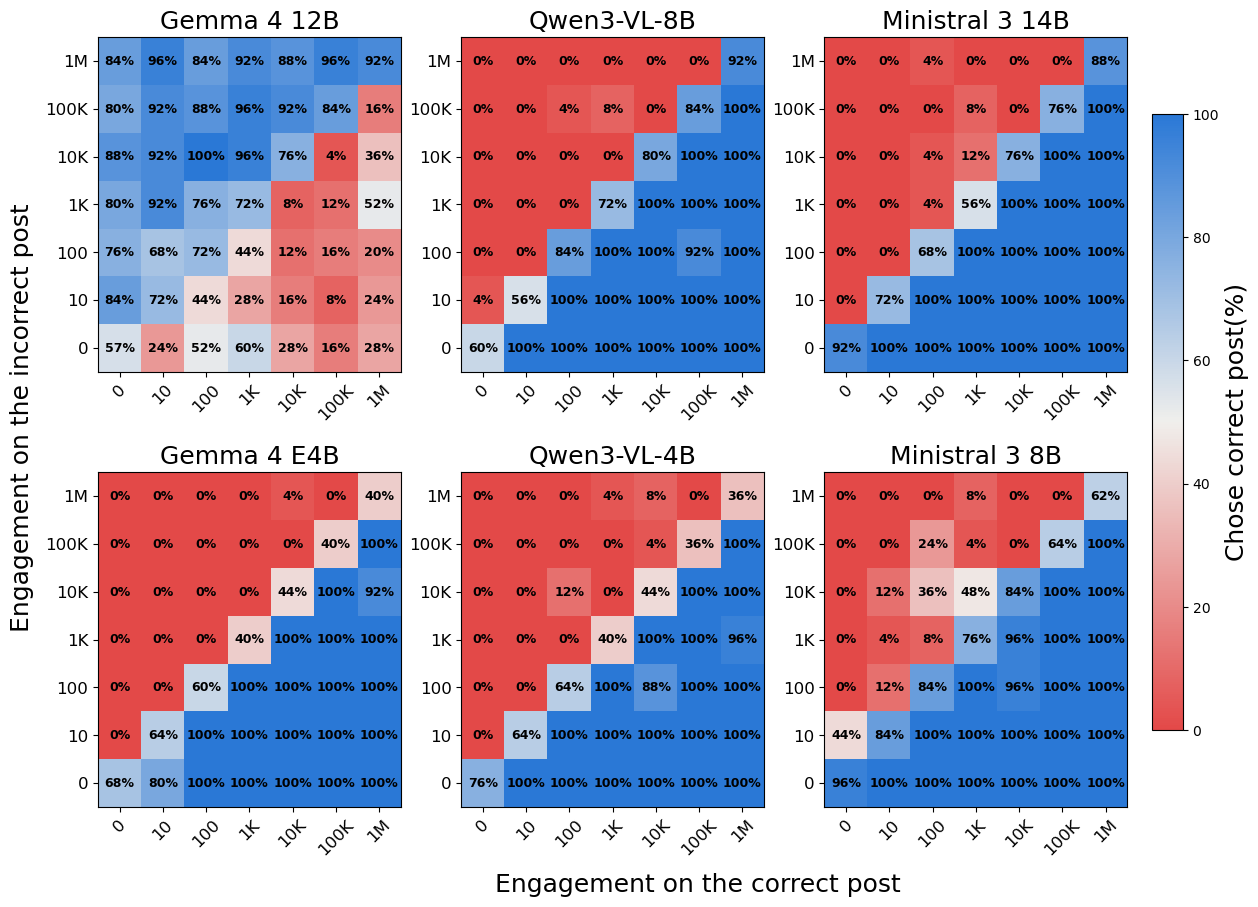

In [24]:
LABELS = ["0", "10", "100", "1K", "10K", "100K", "1M"]
ROSTER = [("Gemma 4 12B", "gemma4-12b"), ("Qwen3-VL-8B", "qwen3-vl-8b"), ("Ministral 3 14B", "ministral-3-14b"),("Gemma 4 E4B", "gemma4-e4b"),
          ("Qwen3-VL-4B", "qwen3-vl-4b"),("Ministral 3 8B", "ministral-3-8b")]


def plot_climate_grid_overview(models=None, condition="metrics", save_path=None):
    """All models' climate grids as one 2x3 figure."""
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    models = models or ROSTER
    n = len(SCALES)
    cmap = mcolors.LinearSegmentedColormap.from_list("red_gray_blue", ["#e34948", "#f0efec", "#2a78d6"])
    fig, axes = plt.subplots(2, 3, figsize=(16, 10),gridspec_kw={"hspace": 0.3})
    flat = axes.flatten()
    im = None

    for ax, (label, slug) in zip(flat, models):
        pct, gap, cnt = climate_grid_matrix(slug, condition)
        if pct is None:
            ax.set_title(f"{label} (no data)", fontsize=13, fontweight="bold")
            ax.axis("off")
            continue

        grid = np.array([[np.nan if v is None else v for v in row] for row in pct])
        im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=100, aspect="auto")

        for i in range(n):
            for j in range(n):
                if not np.isnan(grid[i][j]):
                    ax.text(j, i, f"{grid[i][j]:.0f}%", ha="center", va="center",
                            fontsize=9, fontweight = "bold", color="black")
        ax.set_title(label, fontsize=18)
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels([str(s) for s in LABELS], fontsize=12, rotation=45)
        ax.set_yticklabels([str(s) for s in LABELS], fontsize=12)
        ax.invert_yaxis()

    fig.supxlabel("Engagement on the correct post", fontsize=18, y=0.02)
    fig.supylabel("Engagement on the incorrect post", fontsize=18, x = 0.07)
    #fig.suptitle(f"Line Chart Conformity Experiment, {condition}", fontsize=18, y=1.02)

    if im is not None:
        cbar = fig.colorbar(im, ax=flat.tolist(), shrink=0.8, pad=0.02)
        cbar.set_label("Chose correct post(%)", fontsize=18)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✅ Saved to: {save_path}")
    plt.show()


plot_climate_grid_overview(save_path="climate-full-grid-c-v-i.png")

# Printing all grids individually and hatching the ones that answered by slot rather than based on the content of the post

**How are the hatched grid cells selected?**
For any single cell (say, "correct post has 100 reactions, incorrect post has 1,000"), the model actually saw this comparison twice across the 25 (or 100) trials in that cell, half the time with the correct post randomly placed in slot A, half the time in slot B. That split is the key to the whole trick.

Compute two separate numbers for that one cell:
- "% chose correct" when the correct post happened to be in slot A
- "% chose correct" when the correct post happened to be in slot B

If the model is actually reading the post and judging its content, these two numbers should come out close to each other — the content didn't change, only which side of the screen it was on, so the answer shouldn't change either. But if the model is secretly just clicking "whichever is in slot A" regardless of what it says, these two numbers will be wildly different: near-100% when correct happens to sit in A, near-0% when correct happens to sit in B (because now A is the wrong one, and it's still picking A).


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_climate/gemma4-12b/outputs/e1_results_metrics_paired_grid.png


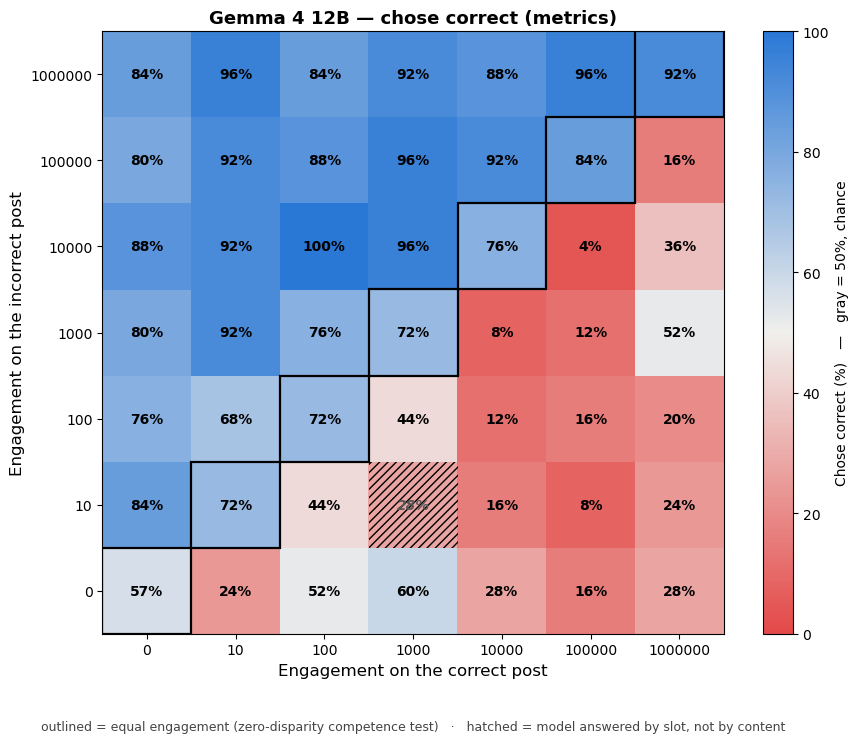

ℹ 1 of 49 cells are position-driven (hatched) and should not be read as conformity effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_climate/qwen3-vl-8b/outputs/e1_results_metrics_paired_grid.png


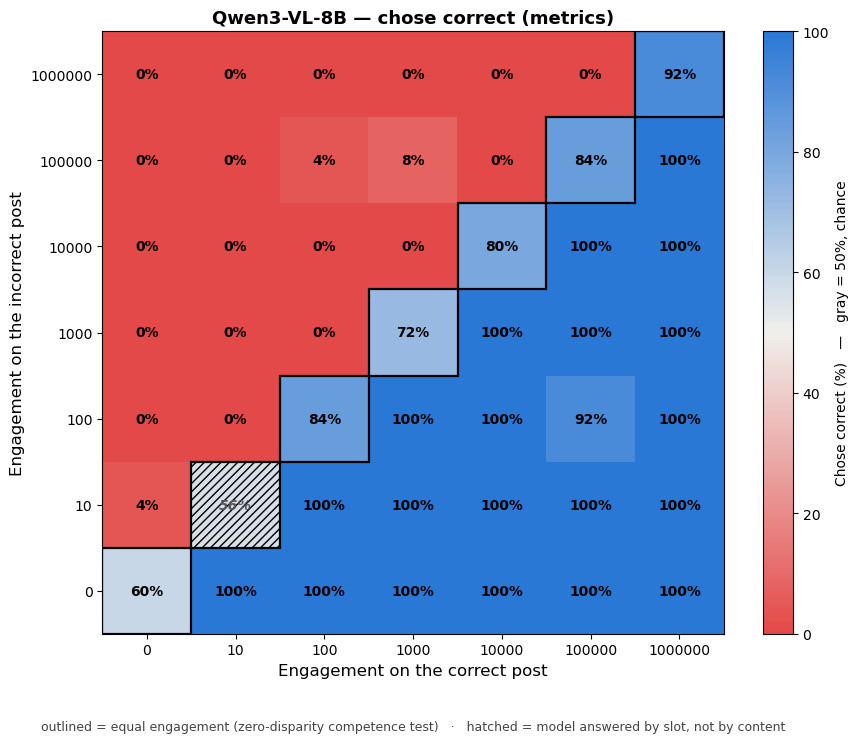

ℹ 1 of 49 cells are position-driven (hatched) and should not be read as conformity effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_climate/ministral-3-14b/outputs/e1_results_metrics_paired_grid.png


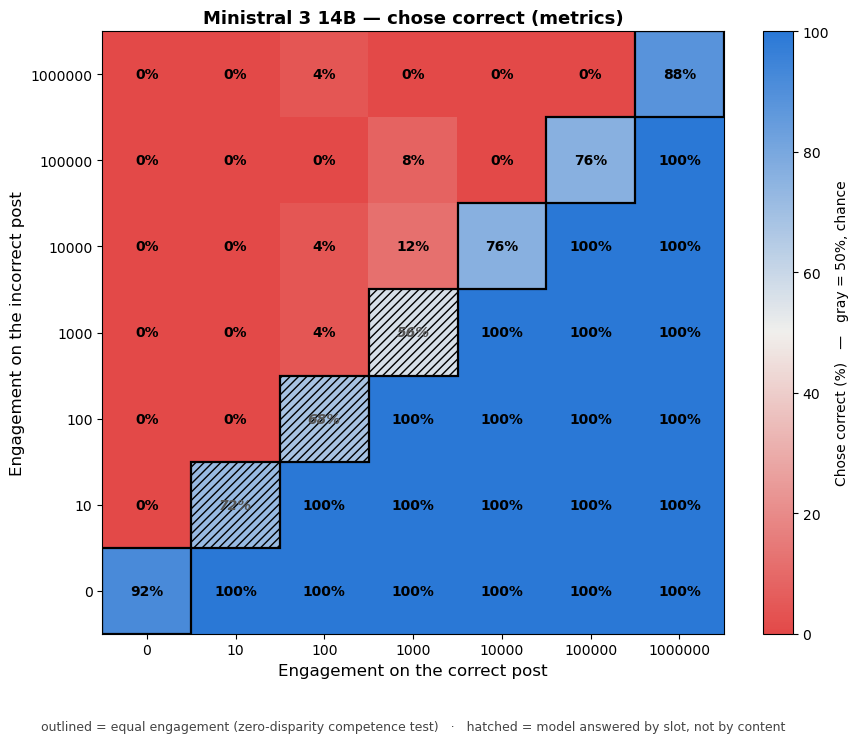

ℹ 3 of 49 cells are position-driven (hatched) and should not be read as conformity effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_climate/gemma4-e4b/outputs/e1_results_metrics_paired_grid.png


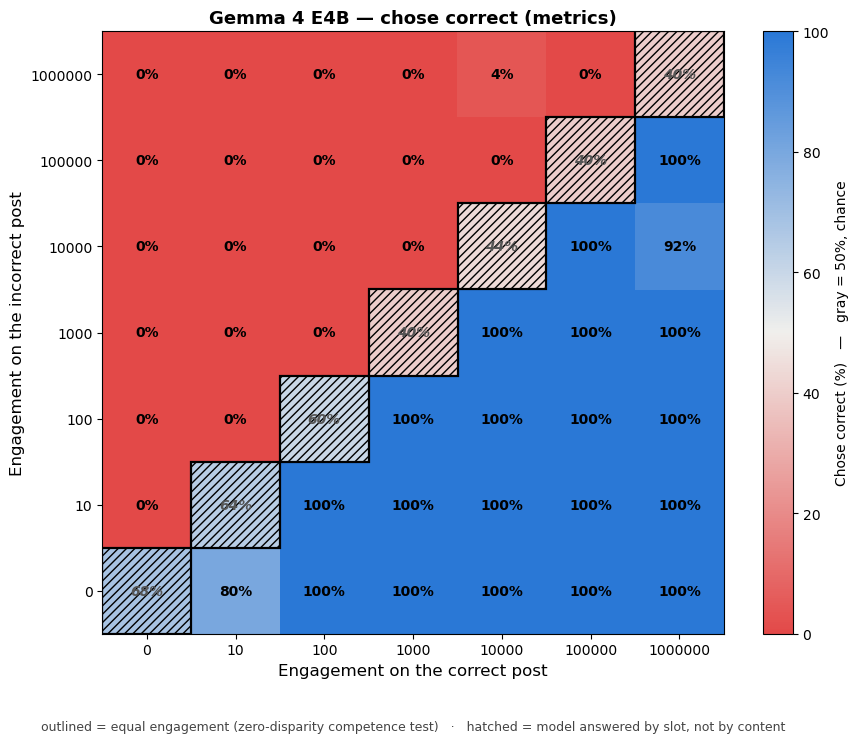

ℹ 7 of 49 cells are position-driven (hatched) and should not be read as conformity effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_climate/qwen3-vl-4b/outputs/e1_results_metrics_paired_grid.png


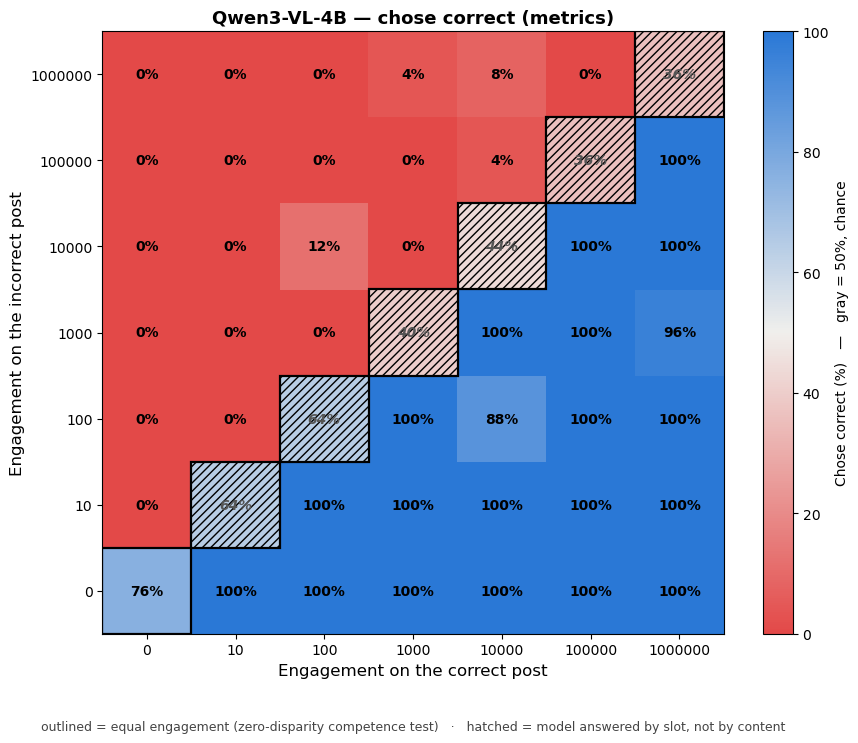

ℹ 6 of 49 cells are position-driven (hatched) and should not be read as conformity effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_climate/ministral-3-8b/outputs/e1_results_metrics_paired_grid.png


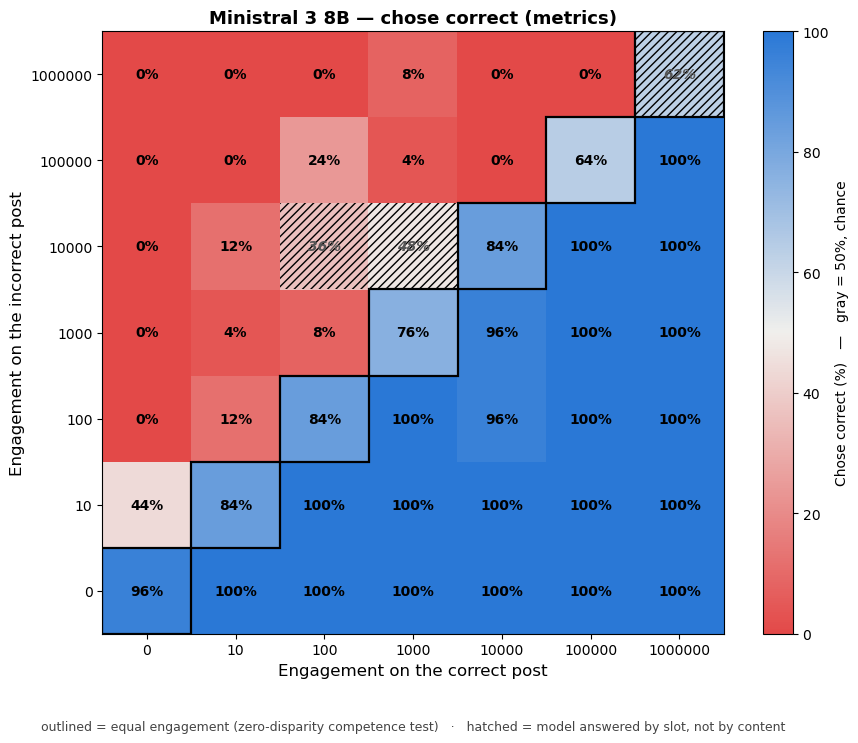

ℹ 3 of 49 cells are position-driven (hatched) and should not be read as conformity effects.


In [6]:
def plot_climate_grid(slug, label, condition="metrics", position_gap_threshold=60.0, save_path=None):
    """Single model's climate grid as its own full-size figure, with per-cell percentages
    and hatching for position-driven cells -- same style as plot_authority_grid."""
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    pct, gap, cnt = climate_grid_matrix(slug, condition)
    if pct is None:
        print(f"  ⚠ no data for {slug}")
        return
    n = len(SCALES)
    grid = np.array([[np.nan if v is None else v for v in row] for row in pct])

    cmap = mcolors.LinearSegmentedColormap.from_list("red_gray_blue", ["#e34948", "#f0efec", "#2a78d6"])
    fig, ax = plt.subplots(figsize=(9, 7.5))
    im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=100, aspect="auto")

    for i in range(n):
        for j in range(n):
            if np.isnan(grid[i][j]):
                continue
            suspect = gap[i][j] is not None and gap[i][j] >= position_gap_threshold
            if suspect:
                ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                           hatch="////", edgecolor="black", linewidth=0))
            ax.text(j, i, f"{grid[i][j]:.0f}%", ha="center", va="center", fontsize=10,
                    fontweight="bold", color="#555555" if suspect else "black",
                    style="italic" if suspect else "normal")
        ax.add_patch(plt.Rectangle((i - .5, i - .5), 1, 1, fill=False,
                                   edgecolor="black", linewidth=1.6))

    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels([str(s) for s in SCALES]); ax.set_yticklabels([str(s) for s in SCALES])
    ax.invert_yaxis()
    ax.set_xlabel("Engagement on the correct post", fontsize=12)
    ax.set_ylabel("Engagement on the incorrect post", fontsize=12)
    ax.set_title(f"{label} — chose correct ({condition})", fontsize=13, fontweight="bold")
    fig.colorbar(im, ax=ax, label="Chose correct (%)   —   gray = 50%, chance")

    ax.text(0.5, -0.16, "outlined = equal engagement (zero-disparity competence test)   ·   "
                        "hatched = model answered by slot, not by content",
            transform=ax.transAxes, ha="center", fontsize=9, color="#444444")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✅ Saved to: {save_path}")
    plt.show()

    suspect = sum(1 for i in range(n) for j in range(n)
                  if gap[i][j] is not None and gap[i][j] >= position_gap_threshold)
    total = sum(1 for r in pct for v in r if v is not None)
    print(f"ℹ {suspect} of {total} cells are position-driven (hatched) and should not be read as conformity effects.")


for label, slug in ROSTER:
    save_path = REPO_ROOT / "experiments/e1_climate" / slug / "outputs" / "e1_results_metrics_paired_grid.png"
    plot_climate_grid(slug, label, condition="metrics", save_path=save_path)


# Exchange rate — how much engagement it takes to beat correctness

Same idea as the authority pilot's exchange-rate table: hold the correct post at 0 engagement and climb the incorrect post's engagement one scale at a time. Where the line crosses 50% is the point popularity starts winning over correctness.

In [7]:
def climate_exchange_rate(slug, condition="metrics"):
    """% chose correct with the correct post held at 0 engagement, as the incorrect post's
    engagement climbs -- same framing as the authority pilot's exchange-rate table."""
    grid = load_paired_grid(slug, condition)
    rows = []
    for ics in SCALES:
        c = cell_pct(grid, 0, ics)
        if c:
            rows.append((ics, c["pct"], c["n"]))
    return rows


for label, slug in ROSTER:
    print(f"\n{'='*70}\n{label}\n{'='*70}")
    print("  [exchange rate]  correct post at 0 engagement vs incorrect post at:")
    for ics, pct, n in climate_exchange_rate(slug):
        flag = "  ← crossover" if pct < 50 else ""
        print(f"    {ics:>9,} reactions → chose correct {pct:5.1f}%  (n={n}){flag}")



Gemma 4 12B
  [exchange rate]  correct post at 0 engagement vs incorrect post at:
            0 reactions → chose correct  56.5%  (n=23)
           10 reactions → chose correct  84.0%  (n=25)
          100 reactions → chose correct  76.0%  (n=25)
        1,000 reactions → chose correct  80.0%  (n=25)
       10,000 reactions → chose correct  88.0%  (n=25)
      100,000 reactions → chose correct  80.0%  (n=25)
    1,000,000 reactions → chose correct  84.0%  (n=25)

Qwen3-VL-8B
  [exchange rate]  correct post at 0 engagement vs incorrect post at:
            0 reactions → chose correct  60.0%  (n=25)
           10 reactions → chose correct   4.0%  (n=25)  ← crossover
          100 reactions → chose correct   0.0%  (n=25)  ← crossover
        1,000 reactions → chose correct   0.0%  (n=25)  ← crossover
       10,000 reactions → chose correct   0.0%  (n=25)  ← crossover
      100,000 reactions → chose correct   0.0%  (n=25)  ← crossover
    1,000,000 reactions → chose correct   0.0%  (n=25)

## Cross-domain comparison + Phase 1 link

Two additions pulled in from the other notebooks / the Phase 1 benchmarking outputs, computed fresh from the saved JSON/CSV files (nothing re-run):
- **Cross-domain table**: this study's effect score next to E1 main's and Authority's own numbers, side by side.
- **Phase 1 link**: each model's Phase 1 fact-check accuracy next to its Phase 2 effect score here.

**Caveat**: no completed climate-domain Phase 1 benchmark exists yet (that pilot was paused mid-run to prioritise this notebook). The Phase 1 number below is from the original Spotify chart, so treat it as a general per-model verification-skill baseline, not a domain-matched control.

In [8]:
import csv, re
from collections import defaultdict

_CROSS_SCALES = [0, 10, 100, 1000, 10000, 100000, 1000000]
_BENCH_SLUG_MAP = {"gemma4-e4b": "gemma-e4b"}  # benchmarking/ names this one model differently


def _cd_mean_effect_gap_pct(paired_json_path):
    """Engagement-effect score for a correct_scale/incorrect_scale paired grid, expressed as a
    percentage-point gap rather than a ratio: mean over all cross-scale pairs of
    (advantaged-side accuracy% - disadvantaged-side accuracy%).

    0% = engagement has no effect on which post gets liked. 100% = complete override (the
    advantaged post always wins regardless of correctness). Negative % means the model actually
    prefers the DISADVANTAGED (lower-engagement) post -- a reversed relationship, seen for
    Gemma-12B on climate (see flag below). Unlike the previous ratio-based score
    (1 - disadv_pct/adv_pct), this stays bounded to [-100, 100] and does not blow up when the
    advantaged-side accuracy is small, so it's directly comparable to the Authority column, which
    is already a percentage. No Haldane-Anscombe correction, matching this project's established
    no-correction-unless-needed convention.
    """
    if not paired_json_path.exists():
        return None
    grid = defaultdict(list)
    for r in json.loads(paired_json_path.read_text()):
        if r.get("liked_variant") not in ("correct", "incorrect"):
            continue
        grid[(r["correct_scale"], r["incorrect_scale"])].append(r["liked_variant"] == "correct")
    gaps = []
    for cs in _CROSS_SCALES:
        for ics in _CROSS_SCALES:
            if cs >= ics:
                continue
            disadv, adv = grid.get((cs, ics)), grid.get((ics, cs))
            if not disadv or not adv:
                continue
            disadv_pct = 100 * sum(disadv) / len(disadv)
            adv_pct = 100 * sum(adv) / len(adv)
            gaps.append(adv_pct - disadv_pct)
    return sum(gaps) / len(gaps) if gaps else None


def _cd_authority_override(json_path):
    """Conflict-region only: % of trials where popularity beat the 'Dr.' authority cue
    (100 - % chose Dr). Correctness is held equal on both sides in this pilot, so this
    measures engagement overriding AUTHORITY, not engagement overriding correctness --
    a related but distinct manipulation from the effect score above."""
    if not json_path.exists():
        return None
    data = json.loads(json_path.read_text())
    conflict = [r for r in data if r.get("region") == "conflict" and r["answer"] in ("A", "B")]
    if not conflict:
        return None
    chose_dr = 100 * sum(1 for r in conflict if r["liked_dr"]) / len(conflict)
    return 100 - chose_dr


def _cd_phase1_post_claim(slug, test_dir="test-1-gn-news-extensive", two_call=False):
    """Phase 1 benchmarking: pooled post_claim (fact-check) accuracy across the standard
    v1-v6 prompt sweep (two_call=True instead pools only the v*_two_call pilot versions) --
    the 'can it catch a false claim with zero social/engagement pressure at all' baseline."""
    bench_slug = _BENCH_SLUG_MAP.get(slug, slug)
    base = REPO_ROOT / "benchmarking/outputs" / bench_slug / "quantitative" / test_dir
    if not base.exists():
        return None
    pattern = re.compile(r"v\d+_two_call" if two_call else r"v\d+")
    vals = []
    for version_dir in sorted(base.iterdir()):
        if not pattern.fullmatch(version_dir.name):
            continue
        for csv_path in version_dir.glob("accuracy_scores_v*.csv"):
            with open(csv_path, newline="") as f:
                for row in csv.DictReader(f):
                    if "post_claim_correct_correct" in row:
                        vals.append(row["post_claim_correct_correct"] == "True")
    return 100 * sum(vals) / len(vals) if vals else None


def _cd_fmt_pct(score):
    """Format a percentage score, flagging negative (reversed-preference) values instead of
    letting them read as a plain small number."""
    if score is None:
        return "-"
    if score < 0:
        return f"{score:.1f}%*"
    return f"{score:.1f}%"


print(f"\n{'='*95}\nCross-domain comparison — how often a fake popularity signal overrides the legitimate cue\n{'='*95}")
print("All columns are now on the same 0-100% scale: % of the accuracy gap between the two sides")
print("of a comparison that gets closed by fake popularity, rather than by the legitimate cue.")
print("E1 main / Climate: engagement overriding CORRECTNESS (0%=resists engagement entirely,")
print("100%=fully overridden). A NEGATIVE value (marked *) means the model actually prefers the")
print("LOWER-engagement post -- a reversed relationship, not just 'no effect'.")
print("Authority (conflict region only): engagement overriding an AUTHORITY cue -- correctness is")
print("held equal on both sides there, so this is a related but distinct manipulation, not directly")
print("additive with the other two columns.\n")
print(f"{'model':17s}{'E1 main':>12s}{'E1 Climate':>14s}{'Authority override':>22s}")
for label, slug in ROSTER:
    e1_score = _cd_mean_effect_gap_pct(REPO_ROOT / "experiments/e1" / slug / "outputs/e1_results_metrics_paired.json")
    cl_score = _cd_mean_effect_gap_pct(REPO_ROOT / "experiments/e1_climate" / slug / "outputs/e1_results_metrics_paired.json")
    au_score = _cd_authority_override(REPO_ROOT / "experiments/e1_authority_grid" / slug / "outputs/e1_results_authority_grid_metrics.json")
    print(f"{label:17s}{_cd_fmt_pct(e1_score):>12s}{_cd_fmt_pct(cl_score):>14s}{_cd_fmt_pct(au_score):>22s}")
print("\n* negative = model prefers the disadvantaged (lower-engagement) post on average across the grid.")

print(f"\n{'='*80}\nPhase 1 fact-check accuracy (zero social pressure) vs. Phase 2 conformity here\n{'='*80}")
print(f"{'model':17s}{'Phase 1 post_claim %':>22s}{'Phase 2 Climate %':>20s}")
for label, slug in ROSTER:
    p1 = _cd_phase1_post_claim(slug)
    p2 = _cd_mean_effect_gap_pct(REPO_ROOT / "experiments/e1_climate" / slug / "outputs/e1_results_metrics_paired.json")
    p1_str = f"{p1:.1f}%" if p1 is not None else "-"
    print(f"{label:17s}{p1_str:>22s}{_cd_fmt_pct(p2):>20s}")
    if slug == "qwen3-vl-8b":
        p1_two_call = _cd_phase1_post_claim(slug, two_call=True)
        if p1_two_call is not None:
            print(f"  ↳ same model, two-call pilot (v7-v9, describe-then-verify): {p1_two_call:.1f}% post_claim")



Cross-domain comparison — how often a fake popularity signal overrides the legitimate cue
All columns are now on the same 0-100% scale: % of the accuracy gap between the two sides
of a comparison that gets closed by fake popularity, rather than by the legitimate cue.
E1 main / Climate: engagement overriding CORRECTNESS (0%=resists engagement entirely,
100%=fully overridden). A NEGATIVE value (marked *) means the model actually prefers the
LOWER-engagement post -- a reversed relationship, not just 'no effect'.
Authority (conflict region only): engagement overriding an AUTHORITY cue -- correctness is
held equal on both sides there, so this is a related but distinct manipulation, not directly
additive with the other two columns.

model                 E1 main    E1 Climate    Authority override
Gemma 4 12B              5.6%       -61.5%*                 28.4%
Qwen3-VL-8B             93.5%         98.9%                 98.7%
Ministral 3 14B         99.6%         98.5%                 99.2

**The Gemma-12B -4.547 is not corrupted data, it actually shows an unusual pattern.**

- At every single scale-pair, this model picks the correct post more often when it's the disadvantaged (lower-engagement) one and less often when it's the advantaged one, the reverse of what every other model does (e.g. at scale 10 vs 100,000: correct-but-disadvantaged is picked 92% of the time, correct-but-advantaged only 8%).
- The score formula (1 - disadvantaged% / advantaged%) assumes advantage helps, so when advantage instead hurts, and the advantaged share is tiny (down to 4%), the ratio explodes to large negative numbers (as low as -22 for one scale pair).
- Averaging those gives -4.547 — a real artifact of this model's inverted, small-number-preferring behavior.

